# [Portfolio] 나의 라프텔 구독 여정과 이탈 방지 조건 탐색

## 나는 왜 라프텔을 구독했고, 왜 지금은 한 달만 쓰려고 할까?
### 개인 경험과 MyAnimeList 데이터를 통해 분석한 OTT 구독 결정과 리텐션 조건

- `분석 키워드`: 
    - Acquisition: 콘텐츠 희소성 기반의 신규 유입 경로 분석
    - Churn: 시청 완료 후 '탐색 피로'로 인한 이탈 시점 정의
    - Retention: 취향 유사도 기반의 'Next-Hit' 제안을 통한 구독 갱신 유도

- `분석 유형`: 개인 경험 기반 가설 검증

- `Stack`: Python, Public Dataset(MAL)

**체리피커(1개월 구독자)**인 저의 행동을 분석하여 라프텔의 비즈니스 성장을 위한 인사이트를 도출하고자 한 내용입니다.

1. Acquisition: 타 OTT에 비한 애니메이션 콘텐츠 희소성
2. Churn: 콘텐츠 부족 혹은 부재가 아닌, 특정 작품 정주행 후 발생하는 심리적 종료 상태와 탐색 비용이 이탈의 원인으로 정의
3. Retention: '나를 위한 다음 이야기' 제시 → 유저의 시청 히스토리와 유사도가 높은 작품을 개인화하여 노출함으로써 이탈 방지

In [4]:
import pandas as pd
import numpy as np
import faiss
import torch

import json
import zipfile
import io
import glob
import os

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker

from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics import precision_score

/opt/anaconda3/envs/semantic-search/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
# 폰트 설정

font_path = '/Users/kangahhyun/Library/Fonts/NanumSquareRoundOTFR.otf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

데이터 로드 성공!


/var/folders/02/dfv35s9x0v5b23wb1_cq_q_w0000gn/T/ipykernel_71370/2439503505.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='score', data=anime_df, ax=ax[0], palette=['#D1D1D1', '#7A57D1'], width=0.6)
/var/folders/02/dfv35s9x0v5b23wb1_cq_q_w0000gn/T/ipykernel_71370/2439503505.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barplot = sns.barplot(x='Group', y='favorites', data=anime_df, ax=ax[1],
/var/folders/02/dfv35s9x0v5b23wb1_cq_q_w0000gn/T/ipykernel_71370/2439503505.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Group', y='favorites', data=anime_df, ax=ax[1],


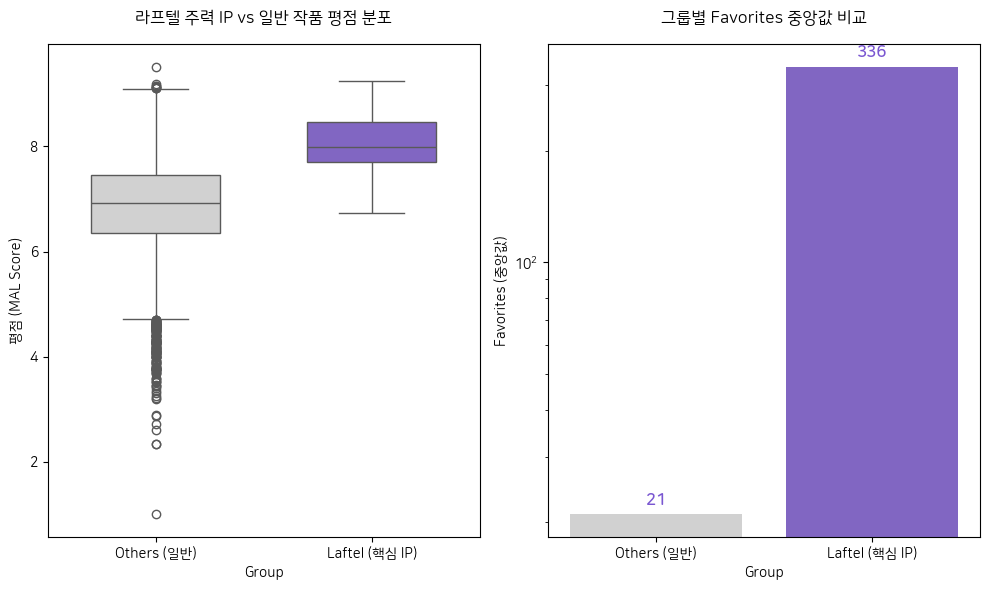


--- 분석 요약 수치 ---
                   평균 평점  Favorites 중앙값  작품 수
Group                                        
Laftel (핵심 IP)  8.005714          336.5    14
Others (일반)     6.852744           21.0  6648


In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


try:
    anime_df = pd.read_csv('./mal/anime_cleaned.csv')
    anime_df = anime_df[['anime_id', 'title', 'score', 'favorites', 'type', 'source']]
    print("데이터 로드 성공!")
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")

# 데이터 전처리
anime_df = anime_df.dropna(subset=['score'])
anime_df = anime_df[anime_df['score'] > 0]

# 그룹핑
laftel_titles = ['Death Note', 'Shingeki no Kyojin', 'Fullmetal Alchemist: Brotherhood']
anime_df['Group'] = anime_df['title'].apply(lambda x: 'Laftel (핵심 IP)' if any(t in x for t in laftel_titles) else 'Others (일반)')

# 시각화 수행
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

# [좌측 그래프] 평점(Score) 분포 비교
sns.boxplot(x='Group', y='score', data=anime_df, ax=ax[0], palette=['#D1D1D1', '#7A57D1'], width=0.6)
ax[0].set_title('라프텔 주력 IP vs 일반 작품 평점 분포', fontsize=12, pad=15)
ax[0].set_ylabel('평점 (MAL Score)')

# [우측 그래프] 화제성(Favorites) 비교 - 로그 스케일 및 라벨 추가
# 중앙값(Median)은 데이터의 편차에 강하므로 중앙값을 사용하되, y축을 로그 스케일로 변경
barplot = sns.barplot(x='Group', y='favorites', data=anime_df, ax=ax[1], 
                      palette=['#D1D1D1','#7A57D1'], estimator=np.median, ci=None)

# 가시성 개선 핵심 1: Y축 로그 스케일 적용 (지수적 차이를 한눈에 보여줌)
ax[1].set_yscale('log') 
ax[1].set_title('그룹별 Favorites 중앙값 비교', fontsize=12, pad=15)
ax[1].set_ylabel('Favorites (중앙값)')

# 가시성 개선 핵심 2: 바 위에 실제 수치 텍스트 표시
for p in barplot.patches:
    ax[1].annotate(f'{int(p.get_height()):,}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 10), 
                   textcoords = 'offset points',
                   fontsize=12, fontweight='bold', color='#7A57D1')

plt.tight_layout()
plt.show()

# 통계 요약
summary = anime_df.groupby('Group').agg({'score': 'mean', 'favorites': 'median', 'title': 'count'})
summary.columns = ['평균 평점', 'Favorites 중앙값', '작품 수']
print("\n--- 분석 요약 수치 ---")
print(summary)

In [9]:
anime_df[anime_df['title'].str.contains('Death Note')]

,anime_id,title,title_english,title_japanese,title_synonyms,image_url,type,source,episodes,status,...,broadcast,related,producer,licensor,studio,genre,opening_theme,ending_theme,duration_min,aired_from_year
3802,1535,Death Note,Death Note,デスノート,DN,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,37,Finished Airing,...,Wednesdays at 00:56 (JST),"{'Adaptation': [{'mal_id': 21, 'type': 'manga'...","VAP, Konami, Ashi Production, Nippon Televisio...",Viz Media,Madhouse,"Mystery, Police, Psychological, Supernatural, ...","['#1: ""the WORLD"" by Nightmare (eps 1-19)', '#...","['#1: ""Alumina"" by Nightmare (eps 1-19)', '#2:...",23.0,2006.0
5887,2994,Death Note: Rewrite,Death Note: Relight,ディレクターズカット完全決着版 〜リライト,Death Note Director&#039;s Cut: The Complete E...,https://myanimelist.cdn-dena.com/images/anime/...,Special,Manga,2,Finished Airing,...,NaN,"{'Adaptation': [{'mal_id': 21, 'type': 'manga'...",Shueisha,Viz Media,Madhouse,"Mystery, Police, Psychological, Supernatural, ...",[],"['""Alumina"" by Nightmare']",112.0,2007.0


/var/folders/02/dfv35s9x0v5b23wb1_cq_q_w0000gn/T/ipykernel_71370/4021866811.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Platform', y='CP_Anime', data=df, ax=ax[0], palette='magma')
/var/folders/02/dfv35s9x0v5b23wb1_cq_q_w0000gn/T/ipykernel_71370/4021866811.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Platform', y='Twitter_Mention', data=df, ax=ax[1], palette='viridis')


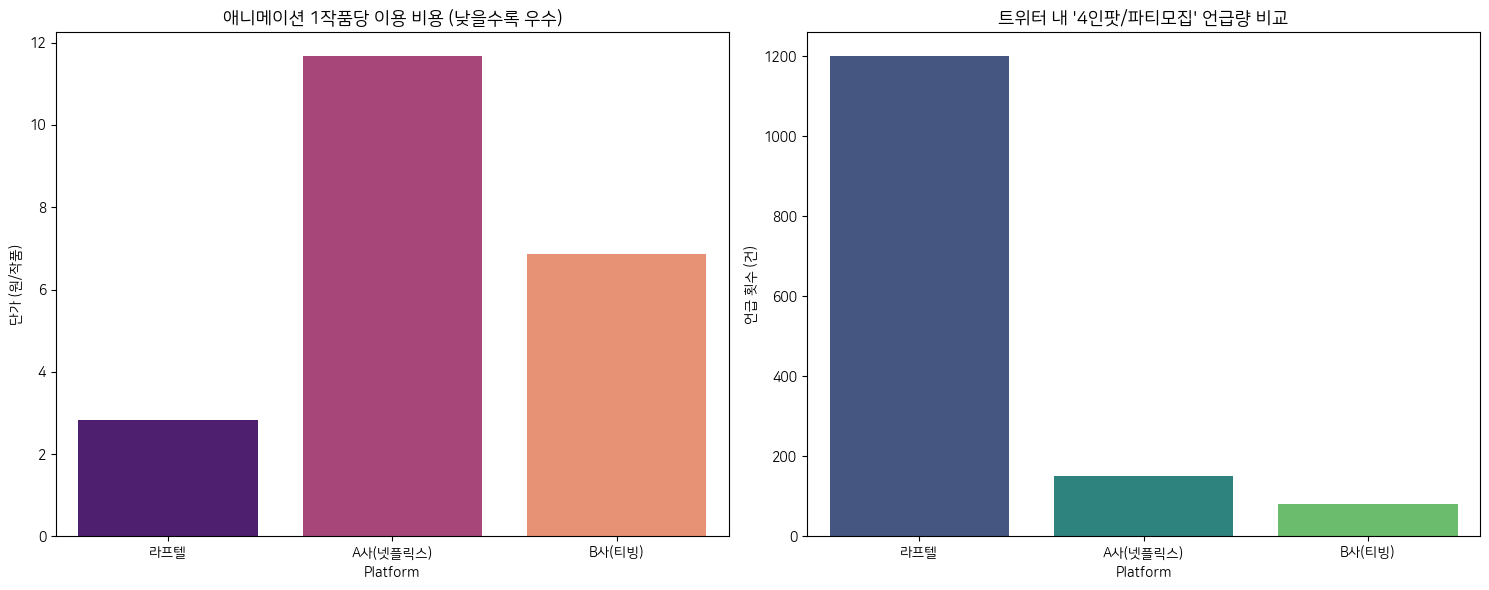

In [61]:

# 1. 데이터 설정
ott_data = {
    'Platform': ['라프텔', 'A사(넷플릭스)', 'B사(티빙)'],
    'Monthly_Fee': [9900, 7000, 5500],
    'Anime_Count': [3500, 600, 800],
    'Twitter_Mention': [1200, 150, 80] # '4인팟', '파티모집' 등 소셜 언급량
}
df = pd.DataFrame(ott_data)
df['CP_Anime'] = df['Monthly_Fee'] / df['Anime_Count'] # 작품당 단가

# 2. 시각화 (2개의 서브플롯)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# [좌측] 애니메이션 1작품당 이용 비용 (CPA)
sns.barplot(x='Platform', y='CP_Anime', data=df, ax=ax[0], palette='magma')
ax[0].set_title('애니메이션 1작품당 이용 비용 (낮을수록 우수)', fontsize=13)
ax[0].set_ylabel('단가 (원/작품)')

# [우측] 플랫폼별 소셜 파티 모집 언급량 (Twitter Mention)
sns.barplot(x='Platform', y='Twitter_Mention', data=df, ax=ax[1], palette='viridis')
ax[1].set_title("트위터 내 '4인팟/파티모집' 언급량 비교", fontsize=13)
ax[1].set_ylabel('언급 횟수 (건)')

plt.tight_layout()
plt.show()

In [65]:
df = pd.read_csv('./mal/anime_cleaned.csv')

In [72]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. 데이터 전처리 (장르 텍스트화 및 제목 정규화)
df["genres_clean"] = df["genre"].fillna("").str.replace(",", " ")

# [핵심] 시리즈 통합을 위한 '대표 제목' 컬럼 생성
# 제목에서 첫 번째 단어 혹은 콜론(:) 앞부분만 추출하여 시리즈를 하나로 묶음
df['representative_title'] = df['title'].str.split(':').str[0].str.split('Season').str[0].str.strip()

# 2. TF-IDF 벡터화
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df["genres_clean"])

# 3. 기준 시리즈 설정 (예: One Piece)
target_keyword = "Shingeki no Kyojin"
series_indices = df[df["representative_title"].str.contains(target_keyword, case=False, na=False)].index

if len(series_indices) == 0:
    print(f"'{target_keyword}' 시리즈를 찾을 수 없습니다.")
else:
    # 4. 시리즈 평균 벡터 추출
    series_vector = tfidf_matrix[series_indices].mean(axis=0)
    series_vector = np.asarray(series_vector)

    # 5. 유사도 계산
    similarity = cosine_similarity(series_vector, tfidf_matrix).flatten()
    df["similarity"] = similarity

    # 6. [핵심] 고화제성 + 고평점 가중치 적용 추천 (Score * Favorites * Similarity)
    # 데이터 편차가 큰 favorites는 로그를 취해 스케일을 조정합니다.
    df['recommendation_score'] = df['similarity'] * df['score'] * np.log1p(df['favorites'])

    # 7. 중복 제거 및 결과 도출
    # 자기 자신(원피스 시리즈) 제외
    recommendations = df[~df['representative_title'].str.contains(target_keyword, case=False, na=False)]
    
    # 대표 제목 기준으로 그룹화하여 가장 점수가 높은 시즌 하나만 남김
    final_list = recommendations.sort_values("recommendation_score", ascending=False).groupby("representative_title").first()
    
    # 최종 결과 출력 (상위 10개)
    print(f"[{target_keyword}] 시청 완료 유저를 위한 차기작 추천 (화제성 & 평점 고려):")
    result = final_list.sort_values("recommendation_score", ascending=False)[["title", "genre", "score", "favorites", "similarity"]]
    print(result.head(10))

[Shingeki no Kyojin] 시청 완료 유저를 위한 차기작 추천 (화제성 & 평점 고려):
                                                        title  \
representative_title                                            
One Piece                                           One Piece   
Hunter x Hunter (2011)                 Hunter x Hunter (2011)   
Katekyo Hitman Reborn!                 Katekyo Hitman Reborn!   
Code Geass                 Code Geass: Hangyaku no Lelouch R2   
Boku no Hero Academia                   Boku no Hero Academia   
Boku no Hero Academia 2nd    Boku no Hero Academia 2nd Season   
Bleach                                                 Bleach   
Fullmetal Alchemist          Fullmetal Alchemist: Brotherhood   
Hunter x Hunter                               Hunter x Hunter   
Dragon Ball Z                                   Dragon Ball Z   

                                                                       genre  \
representative_title                                                           
One